In [1]:
# Read packages and general stuff
import cobra
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib import font_manager
from cobra.sampling import sample
import sys
sys.path.append('../')
from modelfunctions import *

colors = [(r/0xff, g/0xff, b/0xff) for r,g,b in [(0x67, 0x19, 0x70), (0xee, 0x96, 0x4b), 
 (0xb6,0xd0, 0x94), (0x66, 0x00, 0x00), (0xab, 0x81, 0xcd), (0x00, 0x6d, 0x6f),
 (0xe5, 0x62, 0x5e), (0xba, 0xde, 0xfc), (0x87, 0x8e, 0x99), (0x29, 0x70, 0x45),
 (0xff, 0xbf, 0xa0)]]

# use Arial
try: 
    font_path = '/home/emil/.fonts/ARIAL.TTF'  # Your font path goes here
    font_manager.fontManager.addfont(font_path)
    prop = font_manager.FontProperties(fname=font_path)
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = prop.get_name()
except:
    print('Arial font not found, using default')

wd = os.path.abspath(os.getcwd()).removesuffix('Code/accSpecPCM')
figdir = wd + 'Figures/'
acc_spec_wd = f'{wd}Data/analysis/accSpecPCM/'

# EcGEMs 

### Plot about size of the Arabidopsis ecGEM

In [3]:
ara = cobra.io.read_sbml_model(f'{wd}/Data/pcm/ecPCM/Ath.tuned.xml')

Set parameter Username
Set parameter LicenseID to value 2694489
Academic license - for non-commercial use only - expires 2026-08-08


In [8]:
ara.compartments

{'c': 'Cytosol',
 'hm': 'ChloroplastMembrane',
 'h': 'Chloroplast',
 'l': 'ThylakoidLumen',
 'ohm': 'OuterChloroplastEnvelopeMembrane',
 'pg': 'Plastoglobuli'}

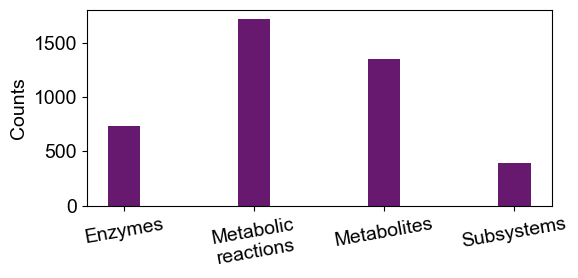

In [5]:
# gather and plot stats
snd_col_idx = 1

def get_ecGEM_stats(ecGEM):

    # check rxns and proteins
    prot_rxns, metab_rxns = [], []
    for r in ecGEM.reactions:
        if 'usage' in r.id or 'prot' in r.id:
            prot_rxns.append(r.id)
        else:
            metab_rxns.append(r.id)
    conv_metab_rids = {get_ori_rid(rid) for rid in metab_rxns}

    # check metabolites
    prot_mets, metab_mets = [], []
    for m in ecGEM.metabolites:
        if 'prot_' in m.id:
            prot_mets.append(m.id)
        else:
            metab_mets.append(m.id)

    return {'nProteins': len(prot_rxns) - 1, 'nMetabRxnsEcGEM': len(metab_rxns), 
            'nMetabRxns': len(conv_metab_rids), 'nMetabMet': len(metab_mets), 'nSubsystems': len(ecGEM.groups)}

def plot_ecGEM_stats(stats, mname_dict, stats_dict, fig_fname = None, plot_xax = True, xlab_rotation = 0, figsize = (4, 3), plot_legend = False):

    plt.figure(figsize=figsize)

    data = stats.loc[list(stats_dict.keys())]
    barWidth = 0.25

    # bars x positions
    r1 = np.arange(data.shape[0])
    r2 = [x + barWidth for x in r1]
    rs = [r1, r2]

    # bars
    for i, mname in enumerate(data.columns):
        plt.bar(rs[i], data[mname], barWidth, color = colors[i * snd_col_idx], label = mname_dict[mname])

    # Add tick labels and titles
    plt.xticks([r + (barWidth * (data.shape[1] - 1) / 2) for r in r1], 
            labels = [stats_dict[stat] for stat in data.index], rotation=xlab_rotation, ha="center" if xlab_rotation <= 20 else "right")
    if not plot_xax:
        plt.tick_params(bottom=False, labelbottom=False)
    plt.ylabel('Counts')

    # legend
    if plot_legend:
        plt.legend(bbox_to_anchor = (0.5, 0.666), ncol=1, frameon=False)

    if fig_fname is not None:
        plt.tight_layout()
        plt.savefig(fig_fname, dpi=300, transparent = True)
    plt.show()
    
stats = pd.DataFrame({'ara': get_ecGEM_stats(ara)})
mname_dict = {'ara': 'Arabidopsis', 'tae': 'T. aestivum'}
stats_dict = {'nProteins': 'Enzymes', 'nMetabRxns': 'Metabolic\nreactions', 
              'nMetabMet': 'Metabolites', 'nSubsystems': 'Subsystems'}

prev_font_size = plt.rcParams['font.size']
plt.rcParams['font.size'] = 14
plot_ecGEM_stats(stats, mname_dict, stats_dict, figdir + 'plast_ara_model_stats.png', xlab_rotation = 10, figsize = (6, 3))
plt.rcParams['font.size'] = prev_font_size

In [6]:
stats

,ara
nProteins,738
nMetabRxnsEcGEM,3602
nMetabRxns,1717
nMetabMet,1351
nSubsystems,395


### Read accession ecPCMs

In [9]:
# set simulation parameters
prot_conds_paper = [48, 65, 118]
prot_bounds = [round(x/65*125) for x in prot_conds_paper]
N_conds = [1, 4, 10]
any_level = prot_bounds[0]

In [10]:
# read models (also needed for plots) takes 2 mins
ecgem_folder = wd + 'Code/gecko/panAraEcPcm/models/'

models = {}
for fname in os.listdir(ecgem_folder):
    if not fname.endswith('.ecModel.tuned.xml'):
        continue
    acc = fname.removesuffix('.ecModel.tuned.xml').removeprefix('Ath.')
    print(f'Loading model of {acc}...', end='      \r')

    models[acc] = cobra.io.read_sbml_model(ecgem_folder + fname)

### Plot about kcat variation

In [11]:
# read kcat data
all_maxs, all_means = {}, {}
for fname in os.listdir(f'{acc_spec_wd}05_comparison_data/kcats/'):
    if not fname.endswith('.csv'):
        continue
    df = pd.read_csv(f'{acc_spec_wd}05_comparison_data/kcats/{fname}')
    acc = fname.removesuffix('.pcm.v23.mat_kcats.csv')
    df.columns = ['rxns', 'kcats']
    df['ori_rxn'] = df['rxns'].apply(lambda s: s[:s.find('_EXP_')] if '_EXP_' in s else s)
    all_maxs[acc] = df.groupby('ori_rxn')['kcats'].max()
    all_means[acc] = df.groupby('ori_rxn')['kcats'].mean()

max_kcats = pd.DataFrame(all_maxs)
def skip_rid(rid):
    return any(rid.startswith(prefix) for prefix in ['t_', 'SLIMEr_', 'Tr_']) or \
        'pool' in rid.lower() or rid == 'BiomassRxn'

rids_to_keep = [rid for rid in max_kcats.index if not skip_rid(rid)]

max_kcats = max_kcats.loc[rids_to_keep]
mean_kcats = pd.DataFrame(all_means).loc[rids_to_keep]

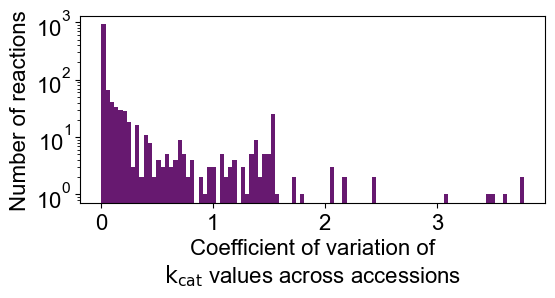

No variation is observed in 873 (66.1 %) of reactions


In [12]:
data = max_kcats.std(axis=1).divide(max_kcats.mean(axis=1))
prev_font_size = plt.rcParams['font.size']
plt.rcParams['font.size'] = 16
plt.figure(figsize = (6, 2.43))
values, ranges, patches = plt.hist(data, bins=100, color=colors[0])

plt.ylabel('Number of reactions')
plt.xlabel('Coefficient of variation of\n' r'$\text{k}_\text{cat}$ values across accessions')
plt.yscale('log')
plt.savefig(figdir + 'CV_kcats_hist.png', transparent=True, dpi=300, bbox_inches='tight')
plt.show()
plt.rcParams['font.size'] = prev_font_size

x = data.loc[~data.isna()]
print(f'No variation is observed in {(x < 1e-6).sum()} ({round(100 * (x < 1e-6).mean(), 1)} %) of reactions')

## Simulation with pFBA

In [13]:
# around 6s total
prot_conds_paper = [48, 65, 118]
prot_bounds = [round(x/65*125) for x in prot_conds_paper]

def simulate_prot_pool(model, bound, exch_bounds = {}):
    with model:
        for rid in exch_bounds:
            get_rid(model, rid).upper_bound = exch_bounds[rid]
        get_rid(model, 'prot_pool_exchange').lower_bound = -bound
        sol = cobra.flux_analysis.pfba(model)

    return sol

sols = {}
for fname in os.listdir(ecgem_folder):
    if not fname.endswith('.ecModel.tuned.xml'):
        continue
    acc = fname.removesuffix('.ecModel.tuned.xml').removeprefix('Ath.')
    print(f'Starting simulation for {acc}...', end='      \r')

    sols[acc] = {}
    for bound in prot_bounds:
        sols[acc][bound] = simulate_prot_pool(models[acc], bound)

In [14]:
# format fluxes from the solutions
# Find the metabolic reactions that are present in all models
inters_rxns = list(set.intersection(*[{get_ori_rid(rid)
                                for rid in sols[acc][any_level].fluxes.index.to_list()
                                if 'prot_' not in rid}
                            for acc in sols]))

# Gather the fluxes through each of the reactions in the conventional model
# full_df: pandas df with Index (prot_bound, rid), Columns (accession)
full_df = pd.concat({pb: pd.DataFrame({acc: sols[acc][pb].fluxes.groupby(get_ori_rid).sum().loc[lambda df:
                                [rid for rid in df.index if get_ori_rid(rid) in inters_rxns]]
                             for acc in sols})
                             for pb in prot_bounds})

full_df.to_csv(f'{acc_spec_wd}05_comparison_data/ecgem_fluxes.csv')

In [15]:
# get enzyme usage for every (conventional) reaction
enz_usages_d = {}
for acc in sols:
    enz_usages_d[acc] = {}
    for level in sols[acc]:
        # use dict for fast item access (24 times faster incl. conversion)
        curr_sol = sols[acc][level].fluxes.to_dict()
        met_rxns = [rid for rid in curr_sol if not rid.startswith('usage_prot') and rid != 'prot_pool_exchange']
        enz_usages_d[acc][level] = {get_ori_rid(rid): 0 for rid in met_rxns}
        for rid in met_rxns:
            for m, f in get_rid(models[acc], rid).metabolites.items():
                if m.id.startswith('prot_') and (rid == 'prot_pool_exchange' or m.id != 'prot_pool'):
                    enz_usages_d[acc][level][get_ori_rid(rid)] -= curr_sol[rid] * f

enz_usages = pd.concat({k: pd.DataFrame(v).T for k, v in enz_usages_d.items()}, axis=0).stack(future_stack=True).unstack(0)
enz_usages.to_csv(f'{acc_spec_wd}05_comparison_data/ecgem_enz_usages.csv')

## Read results and make plots

In [16]:
acc_colors = {'Bay_0': (0.7137254901960784, 0.8156862745098039, 0.5803921568627451),
 'Tsu_0': (0.4, 0.0, 0.0),
 'Tanz_1': (0.6705882352941176, 0.5058823529411764, 0.803921568627451),
 'Sah_0': (0.0, 0.42745098039215684, 0.43529411764705883),
 'Yo_0': (0.403921568627451, 0.09803921568627451, 0.4392156862745098),
 'Bla_1': (0.7294117647058823, 0.8705882352941177, 0.9882352941176471),
 'Taz_0': (0.9333333333333333, 0.5882352941176471, 0.29411764705882354),
 'Tul_0': (0.5294117647058824, 0.5568627450980392, 0.6),
 'Bur_0': (0.1607843137254902, 0.4392156862745098, 0.27058823529411763),
 'Shahdara': (0.8980392156862745, 0.3843137254901961, 0.3686274509803922),
 'Col_0': (1.0, 0.7490196078431373, 0.6274509803921569),
 'Ishikawa': (0.09420883275304903, 0.6291104599922431, 0.6824609344562551),
 'Jea': (0.43295705596247447, 0.977306284453068, 0.7149742169030798),
 'Are_2': (0.7295717741268839, 0.13649403034894358, 0.19796436224306502),
 'Kyr_1': (0.9959886544597308, 0.9734492909139295, 0.8321033597324019),
 'Zin9': (0.9464595039109757, 0.9743493484289852, 0.39480811242266334),
 'Sus_1': (0.0, 0.5, 0.0),
 'Are_1': (0.9323878060021565, 0.6217871261248432, 0.9714098047064589),
 'N13': (0.4893595127800914, 0.568091895766057, 0.24836263274487747),
 'Are_6': (0.03832082855633301, 0.01759986003474967, 0.3126032308147183),
 'ws_4': (0.9429869673601893, 0.32719541527657214, 0.0027378078024445918)}

# translate from reaction ID to reaction name
rid2rname = {}
for acc in models:
    for r in models[acc].reactions:
        if get_ori_rid(r.id) not in rid2rname:
            rid2rname[get_ori_rid(r.id)] = r.name

In [17]:
flux_df = pd.read_csv(f'{acc_spec_wd}05_comparison_data/ecgem_fluxes.csv', index_col = [0,1])
enz_usages = pd.read_csv(f'{acc_spec_wd}05_comparison_data/ecgem_enz_usages.csv', index_col = [0,1])

### Plot total protein content and rubisco usage

In [18]:
ecgem_folder = wd + 'Code/gecko/panAraEcPcm/models/'
prot_conds_paper = [48, 65, 118]
prot_bounds = [round(x/65*125) for x in prot_conds_paper]

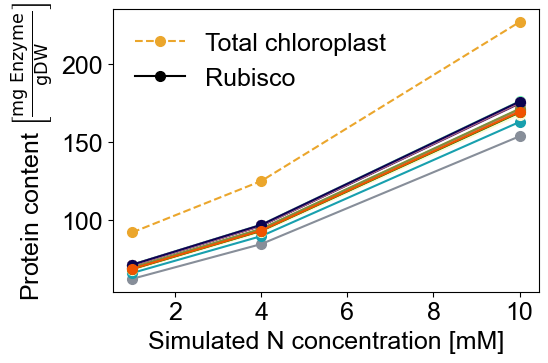

In [19]:
plt.figure(figsize=(5.5,3.67))
prev_font_size = plt.rcParams['font.size']
plt.rcParams['font.size'] = 18
lw, ms = 1.5, 7

# protein pool limit
prot_pool_col = (0xEC/256, 0xA7/256, 0x2C/256)
plt.plot(N_conds, prot_bounds, '--o', color = prot_pool_col, linewidth=lw, markersize = ms,)

# rubisco enzyme abundance
patches, labels = [], []
for acc in enz_usages.columns:
    y_data = enz_usages[acc].unstack()[['RBC_h', 'RBO_h']].sum(axis=1)
    label = acc.replace('_', '-')
    patches += plt.plot(N_conds, y_data, '-o', linewidth=lw, markersize = ms, label=label, color = acc_colors[acc])
    labels.append(label)

# plot adjustments
plt.xlabel('Simulated N concentration [mM]')
plt.ylabel(r'Protein content $\left[\frac{\text{mg Enzyme}}{\text{gDW}}\right]$')

plt.legend(handles = [mpl.lines.Line2D([], [], linestyle = '--', marker = 'o', linewidth=lw, markersize = ms, color=prot_pool_col),
                      mpl.lines.Line2D([], [], linestyle = '-', marker = 'o', linewidth=lw, markersize = ms, color='k')],
           labels = ['Total chloroplast', 'Rubisco'],
           loc = 'upper left', frameon=False, columnspacing=1)
           
plt.savefig(figdir + 'plast_overview.png', transparent=True, dpi=300, bbox_inches='tight')
plt.show()

plt.rcParams['font.size'] = prev_font_size

### Plot flux reaction norms

In [25]:
def plot_rxn_norm(rid, flux_df = flux_df, N_conds = N_conds, ylabel_first_line = 'Flux prediction through', 
                  plot_legend = False, rname = None, savename = None, lw = 1.5, ms = 7, acc_colors = acc_colors,
                  plot_xaxis = True, slides_friendly = False, ylog = False, xlog = False):
    plt.figure(figsize=(5.5,2.5 if slides_friendly else 3.67 * (0.95 if plot_xaxis else 1)))
    prev_font_size = plt.rcParams['font.size']
    plt.rcParams['font.size'] = 18
    patches, labels = [], []
    for acc_i, acc in enumerate(flux_df.columns):
        try:
            y_data = flux_df[acc].xs(rid, level=1).to_numpy()
        except KeyError:
            tmp = flux_df[acc].unstack().T
            y_data = tmp.loc[[x for x in tmp.index if rid in x]].sum().to_numpy()
        label = acc.replace('_', '-')
        patches += plt.plot(N_conds, y_data, '-o', label=label, color = acc_colors[acc], lw=lw, markersize=ms)
        labels.append(label)

        plt.ylabel(f'{ylabel_first_line}\n{rid if rname is None else rname}')
        if plot_xaxis:
            plt.xlabel('Simulated N concentration [mM]')
        else:
            plt.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

    if ylog:
        plt.yscale('log')
    if xlog:
        plt.xscale('log')
    if plot_legend:
        plt.legend(handles = [mpl.lines.Line2D([], [], marker = 'o', linewidth=0, markersize = 10, color=p.get_color())
                              for p in patches], labels = labels,
                   ncol=7, bbox_to_anchor=(-0.40, 1.05), frameon=False, columnspacing=0.8)
    
    if savename is not None:
        if plot_legend:
            savename = savename[:savename.rfind('.')] + '_legend' + savename[savename.rfind('.'):]
        plt.savefig(figdir + savename, transparent=True, dpi=300, bbox_inches='tight')
    plt.show()
    
    plt.rcParams['font.size'] = prev_font_size

In [21]:
# Gather stats of how many reactions show clear GxE
rxns_some_0 = flux_df.loc[(flux_df == 0).any(axis=1) & ~(flux_df == 0).all(axis=1)].index.get_level_values(1).unique()
all_rxns = flux_df.loc[any_level].index.to_list()
any_zero = rxns_some_0.to_list()
print(f'Of {len(all_rxns)}, in {len(any_zero)} ({round(100 * len(any_zero)/len(all_rxns), 1)} %) at least one accession has 0 flux (but not all accessions)')

Of 1369, in 152 (11.1 %) at least one accession has 0 flux (but not all accessions)


In [22]:
# Gather information which subsystems are affected by this GxE
subs = {}
for rid in any_zero:
    for acc in models:
        try:
            r = get_rid(models[acc], rid)
        except KeyError:
            continue
        for gr in models[acc].groups:
            if r in gr.members:
                subs[gr.name] = subs.get(gr.name, 0) + 1
        break
pd.Series(subs).sort_values(ascending = False).head(20)

SLIME pseudo reaction                                53
2-Oxocarboxylic acid metabolism                      13
Valine, leucine and isoleucine biosynthesis          10
galactolipid synthesis, prokaryotic pathway           9
transport                                             7
export                                                6
C5-Branched dibasic acid metabolism                   5
MetaCyc:L-valine biosynthesis                         4
MetaCyc:sucrose biosynthesis II                       3
Pantothenate and CoA biosynthesis                     3
Glycolysis / Gluconeogenesis                          3
Starch and sucrose metabolism                         3
MetaCyc:sucrose degradation II (sucrose synthase)     3
Arginine and proline metabolism                       3
Glycine, serine and threonine metabolism              3
diacylglycerol synthesis, chloroplast                 3
MetaCyc:starch biosynthesis                           3
MetaCyc:glyoxylate cycle                        

In [23]:
# translate from reaction ID to reaction name
rid2rname = {}
for acc in models:
    for r in models[acc].reactions:
        if get_ori_rid(r.id) not in rid2rname:
            rid2rname[get_ori_rid(r.id)] = r.name

# select the reactions to plot and what name to display
candidates = ['R00105', 'R04441']
rid2rname['R00105'] = 'NADH kinase'
rid2rname['R04441'] = 'Dihydroxy acid dehydrase'

R00105 NADH kinase


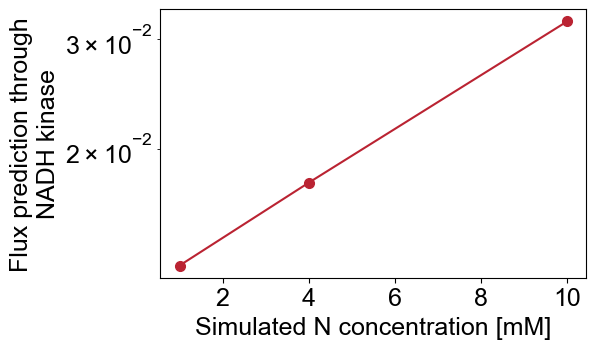

R04441 Dihydroxy acid dehydrase


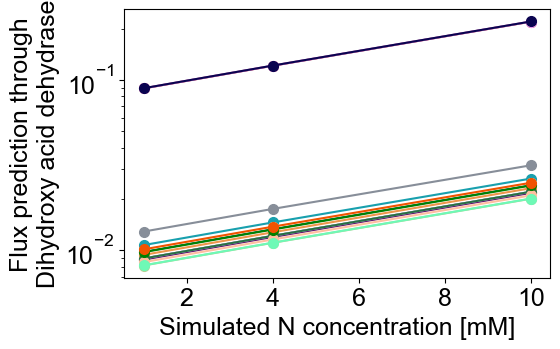

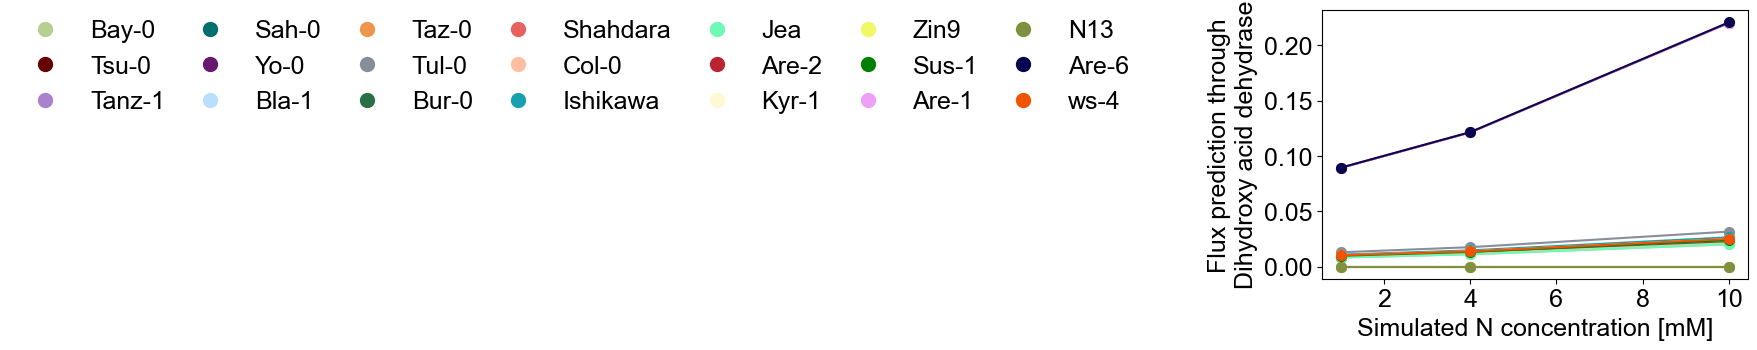

In [ ]:
# plots
for rid in candidates:
    try:
        rname = rid2rname[rid]
    except KeyError:
        for rid_it in rid2rname:
            if rid in rid_it:
                rname = rid2rname[rid_it]
                break 
    print(rid, rname)

    plot_rxn_norm(rid, rname = rname, savename = f'acc_plast_{rid}.png')

# Plot it once again with the legend
plot_rxn_norm(rid, plot_legend = True, rname = rid2rname[rid], savename = f'acc_plast_{rid}.png')